### BENCHMARKING VISUALISATIONS

Developed and run with Python 3.13.9

In [19]:
# ----------------------------------------------------
# imports
# ----------------------------------------------------
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# configurations
# ----------------------------------------------------

RESULTS_DIR = Path("results")

parametersets = [
    "sha2-128s", "sha2-128f",
    "sha2-192s", "sha2-192f",
    "sha2-256s", "sha2-256f",
    "shake-128s", "shake-128f",
    "shake-192s", "shake-192f",
    "shake-256s", "shake-256f",
]

implementations = ["jasmin_ref", "jasmin_avx2", "c_ref", "openssl"]

actions = ["keygen", "sign", "verify"]

OUTPUT_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)

# ----------------------------------------------------
# separate the parts making up a parameter set,
# e.g. "sha2-128s" -> ("sha2", 128, "s")
# ----------------------------------------------------
def parse_paramset(ps):
    algo, rest = ps.split("-")
    size = int(rest[:-1])
    tradeoff = rest[-1]
    return algo, size, tradeoff

In [20]:
# ----------------------------------------------------
# load all cycle measurement benchmark data
# data structure:
# benchmark_data[impl][paramset][action] = np.array(...)
# ----------------------------------------------------

def load_cycles(filepath):
    cycles = []
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                cycles.append(int(line))
    return np.array(cycles, dtype=np.int64)

benchmark_data = {impl: {} for impl in implementations}

def trim_outliers(data, upper_percent=95.0):
    upper = np.percentile(data, upper_percent)
    return data[data <= upper]

for impl in implementations:
    for paramset in parametersets:
        for action in actions:

            filename = f"{impl}_{paramset}_{action}.txt"
            filepath = RESULTS_DIR / filename

            if not filepath.exists():
                print(f"[WARNING] Missing file: {filepath}")
                continue

            cycles = load_cycles(filepath)

            # remove extreme 5% total
            cycles = trim_outliers(cycles)

            benchmark_data.setdefault(impl, {}).setdefault(paramset, {})[action] = cycles

In [21]:

# ----------------------------------------------------
# compute left/right split violin data sets
# ----------------------------------------------------
def split_violin(ax, data_left, data_right, positions, impl_left, impl_right, width=0.8):

    vp_left = ax.violinplot(
        data_left,
        positions=positions,
        widths=width,
        showmeans=False,
        showmedians=False
    )

    vp_right = ax.violinplot(
        data_right,
        positions=positions,
        widths=width,
        showmeans=False,
        showmedians=False
    )

    # ----------------------------------------------------
    # style and clipping
    # ----------------------------------------------------
    for body in vp_left["bodies"]:
        if impl_left == "jasmin_ref":
            body.set_facecolor("tab:blue")
        elif impl_left == "jasmin_avx2":
            body.set_facecolor("tab:purple")
        elif impl_left == "c_ref":
            body.set_facecolor("tab:orange")
        elif impl_left == "openssl":
            body.set_facecolor("tab:green")
        else:
            body.set_facecolor("tab:blue")
        body.set_alpha(1)
        body.set_edgecolor("black")
        body.set_linewidth(0.5)
        body.set_zorder(2)

        path = body.get_paths()[0]
        verts = path.vertices
        center = np.mean(verts[:, 0])
        verts[verts[:, 0] > center, 0] = center

    for body in vp_right["bodies"]:
        if impl_right == "jasmin_ref":
            body.set_facecolor("tab:blue")
        elif impl_right == "jasmin_avx2":
            body.set_facecolor("tab:purple")
        elif impl_right == "c_ref":
            body.set_facecolor("tab:orange")
        elif impl_right == "openssl":
            body.set_facecolor("tab:green")
        else:
            body.set_facecolor("tab:orange")
        body.set_alpha(1)
        body.set_edgecolor("black")
        body.set_linewidth(0.5)
        body.set_zorder(2)

        path = body.get_paths()[0]
        verts = path.vertices
        center = np.mean(verts[:, 0])
        verts[verts[:, 0] < center, 0] = center

    # ----------------------------------------------------
    # remove min/max whiskers and extras
    # ----------------------------------------------------
    for pc in ["cmins", "cmaxes", "cbars"]:
        if pc in vp_left:
            vp_left[pc].set_visible(False)
        if pc in vp_right:
            vp_right[pc].set_visible(False)

    return vp_left, vp_right

def plot_violin_grid(all_data, algo_filter, impl_left, impl_right):

    sizes = [128, 192, 256]
    tradeoffs = ["f", "s"]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(9,6),
        sharey=False
    )

    for i, tradeoff in enumerate(tradeoffs):
        for j, action in enumerate(actions):

            ax = axes[i, j]

            # ----------------------------------------------------
            # separate data per implementation
            # ----------------------------------------------------
            left_data = {128: [], 192: [], 256: []}
            right_data = {128: [], 192: [], 256: []}

            for impl in implementations:
                if impl == impl_left or impl == impl_right:
                    for ps, action_dict in all_data[impl].items():

                        algo, size, t = parse_paramset(ps)

                        if algo != algo_filter:
                            continue
                        if t != tradeoff:
                            continue
                        if action not in action_dict:
                            continue

                        if impl == impl_left:
                            left_data[size].extend(action_dict[action])
                        elif impl == impl_right:
                            right_data[size].extend(action_dict[action])

            # ----------------------------------------------------
            # convert to ordered lists
            # ----------------------------------------------------
            data_left = [left_data[s] for s in sizes]
            data_right = [right_data[s] for s in sizes]

            positions = [1.0, 1.8, 2.6]

            # ----------------------------------------------------
            # plot split violins
            # ----------------------------------------------------
            split_violin(ax, data_left, data_right, positions, impl_left, impl_right)

            # ----------------------------------------------------
            # draw median lines manually
            # (commented out as the distributions are so narrow that
            #  the median lines are just visual clutter)
            # ----------------------------------------------------
            # for idx, pos in enumerate(positions):

            #     # left
            #     if len(data_left[idx]) > 0:
            #         med_left = np.median(data_left[idx])

            #         ax.plot(
            #             [pos - 0.1, pos],
            #             [med_left, med_left],
            #             color="white",
            #             linewidth=1.0,
            #             solid_capstyle="round"
            #         )

            #     # right
            #     if len(data_right[idx]) > 0:
            #         med_right = np.median(data_right[idx])

            #         ax.plot(
            #             [pos, pos + 0.1],
            #             [med_right, med_right],
            #             color="white",
            #             linewidth=1.0,
            #             solid_capstyle="round"
            #         )

            ax.set_xticks(positions)
            ax.set_xticklabels(["128", "192", "256"])

            ax.set_title(f"{action} ({tradeoff})")
            ax.grid(True, zorder=0)

            ax.set_ylim(bottom=0)

            if i == 1:
                ax.set_xlabel("Parameter size")
            if j == 0:
                ax.set_ylabel("Cycles")

    plt.tight_layout(rect=[0, 0, 1, 0.965])

    # save the plot as a vector graphics .pdf file
    output_file = (OUTPUT_DIR / f"violin_{algo_filter}_{impl_left}_vs_{impl_right}.pdf")
    plt.savefig(
        output_file,
        bbox_inches="tight"
    )

    plt.show()

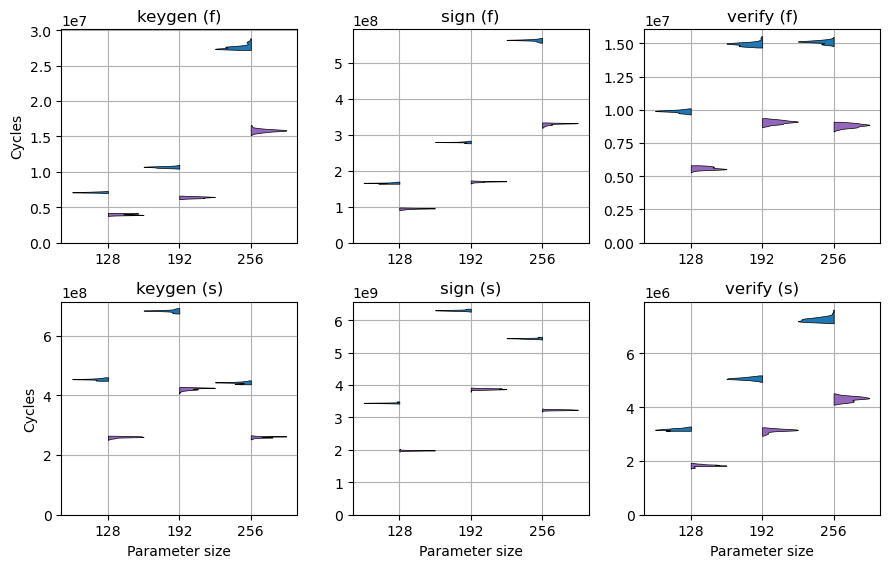

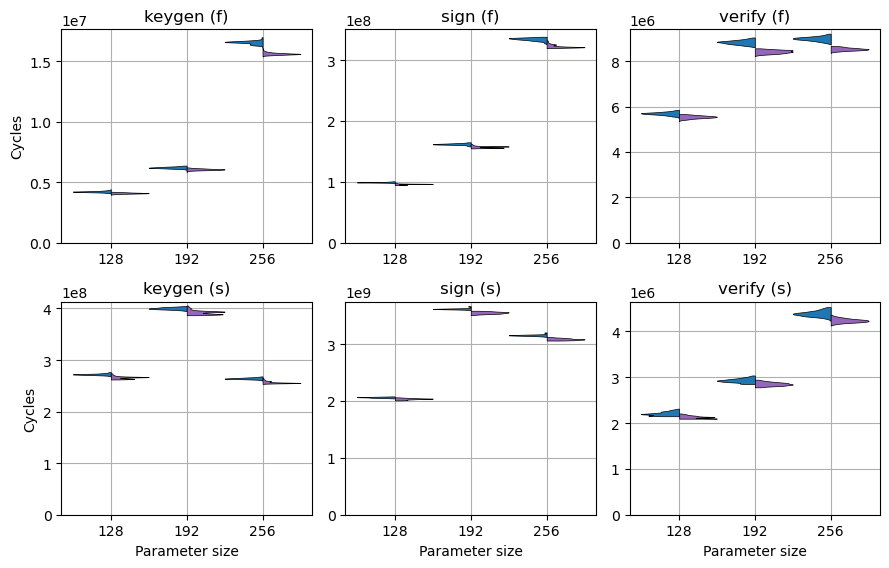

In [22]:
# visualise violin plot grid for SHA2 and SHAKE,
# comparing the Jasmin reference and AVX (optimised) implementations

plot_violin_grid(benchmark_data, "sha2", "jasmin_ref", "jasmin_avx2")
plot_violin_grid(benchmark_data, "shake", "jasmin_ref", "jasmin_avx2")

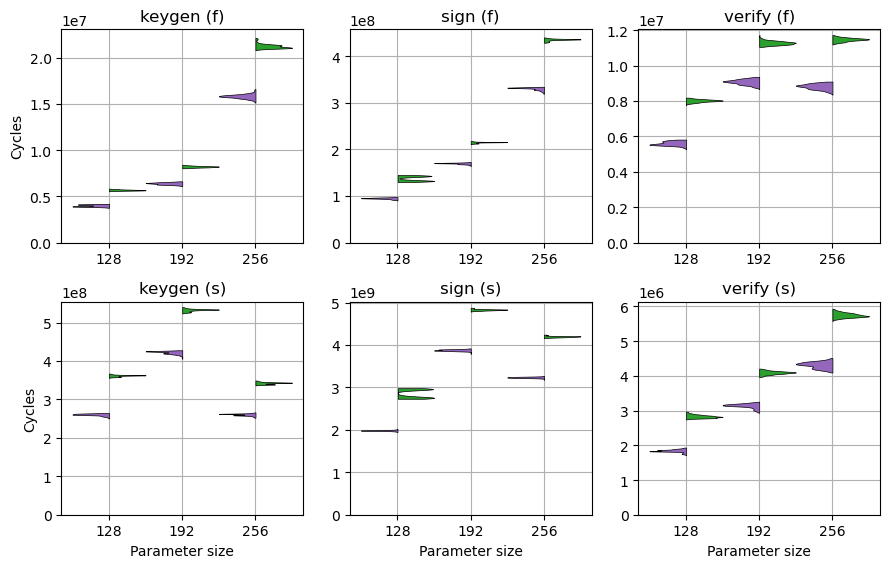

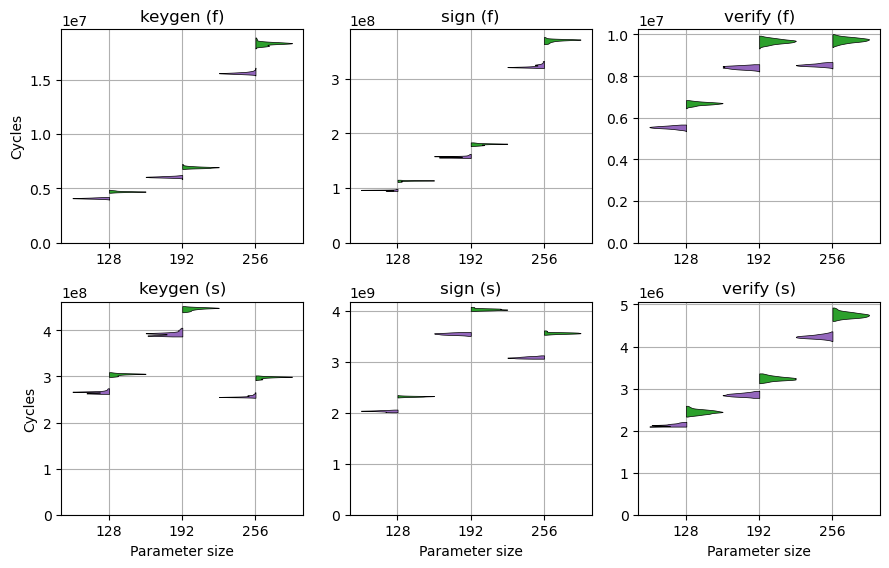

In [23]:
# visualise violin plot grid for SHA2 and SHAKE,
# comparing the Jasmin AVX2 (optimised) and OpenSSL implementations

plot_violin_grid(benchmark_data, "sha2", "jasmin_avx2", "openssl")
plot_violin_grid(benchmark_data, "shake", "jasmin_avx2", "openssl")

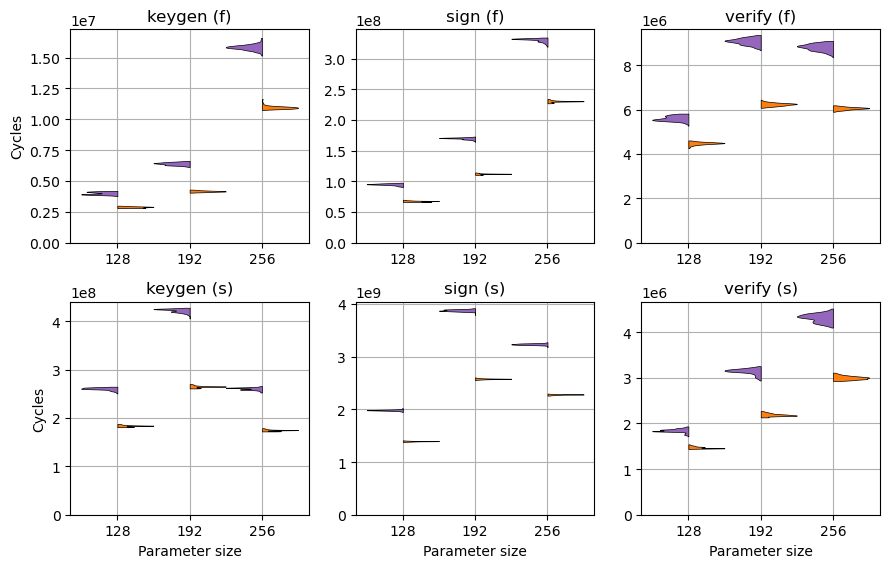

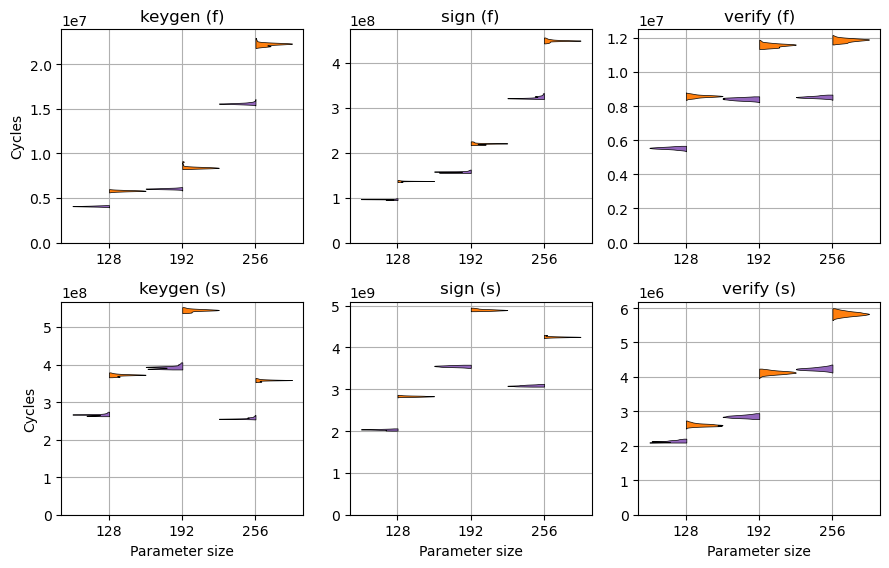

In [24]:
# visualise violin plot grid for SHA2 and SHAKE,
# comparing the Jasmin AVX2 and C reference implementations

plot_violin_grid(benchmark_data, "sha2", "jasmin_avx2", "c_ref")
plot_violin_grid(benchmark_data, "shake", "jasmin_avx2", "c_ref")

In [25]:
# ----------------------------------------------------
# Compute median cycle counts
# ----------------------------------------------------

median_table = {}

for action in actions:
    median_table[action] = {}

    for algo in ["sha2", "shake"]:
        for size in [128, 192, 256]:
            for tradeoff in ["f", "s"]:

                paramset = f"{algo}-{size}{tradeoff}"

                median_table[action][paramset] = {}

                for impl in implementations:

                    if (
                        paramset in benchmark_data.get(impl, {})
                        and action in benchmark_data[impl][paramset]
                    ):
                        cycles = benchmark_data[impl][paramset][action]
                        median_table[action][paramset][impl] = int(np.median(cycles))
                    else:
                        median_table[action][paramset][impl] = None

In [26]:
# ----------------------------------------------------
# Print LaTeX table
# ----------------------------------------------------

column_names = {
    "jasmin_ref": "Jasmin ref",
    "jasmin_avx2": "Jasmin AVX2",
    "c_ref": "C ref",
    "openssl": "OpenSSL",
}

print(r"\begin{tabular}{ll|rrrr}")
print(r"\textbf{Action} & \textbf{Param.} & \textbf{Jasmin ref} & \textbf{Jasmin AVX2} & \textbf{C ref} & \textbf{OpenSSL} \\")

for action in ["keygen", "sign", "verify"]:
    print(r"\hline")

    for algo in ["sha2", "shake"]:
        for size in [128, 192, 256]:
            for tradeoff in ["f", "s"]:

                paramset = f"{algo}-{size}{tradeoff}"

                values = []

                for impl in [
                    "jasmin_ref",
                    "jasmin_avx2",
                    "c_ref",
                    "openssl",
                ]:

                    value = median_table[action][paramset].get(impl)

                    if value is None:
                        values.append("--")
                    else:
                        values.append(f"{value:,}")

                print(
                    f"{action}"
                    f" & {paramset}"
                    f" & {values[0]}"
                    f" & {values[1]}"
                    f" & {values[2]}"
                    f" & {values[3]} \\\\"
                )

print(r"\end{tabular}")

\begin{tabular}{ll|rrrr}
\textbf{Action} & \textbf{Param.} & \textbf{Jasmin ref} & \textbf{Jasmin AVX2} & \textbf{C ref} & \textbf{OpenSSL} \\
\hline
keygen & sha2-128f & 7,116,501 & 3,995,859 & 2,878,281 & 5,672,751 \\
keygen & sha2-128s & 453,864,222 & 260,829,723 & 183,844,038 & 362,398,113 \\
keygen & sha2-192f & 10,683,435 & 6,407,793 & 4,156,530 & 8,209,572 \\
keygen & sha2-192s & 683,307,702 & 423,440,115 & 264,837,867 & 533,332,926 \\
keygen & sha2-256f & 27,551,181 & 15,837,990 & 10,944,948 & 21,205,674 \\
keygen & sha2-256s & 443,070,411 & 261,561,783 & 174,825,126 & 342,933,518 \\
keygen & shake-128f & 4,202,520 & 4,084,773 & 5,812,674 & 4,691,127 \\
keygen & shake-128s & 272,243,307 & 266,779,485 & 372,608,670 & 305,503,002 \\
keygen & shake-192f & 6,191,430 & 6,044,451 & 8,397,690 & 6,923,154 \\
keygen & shake-192s & 400,193,871 & 393,122,970 & 545,133,435 & 448,323,539 \\
keygen & shake-256f & 16,563,519 & 15,591,786 & 22,279,593 & 18,331,467 \\
keygen & shake-256s & 264,